# Phân Tích Dữ Liệu Đơn Biến Trên Dữ Liệu Chim Cánh Cụt

Notebook này thực hiện phân tích đơn biến trên dữ liệu chim cánh cụt (Penguins) từ dataset Palmer Archipelago Antarctica trên Kaggle: [https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data).

Dataset bao gồm **hai file chính**:
- **penguins_size.csv**: Dữ liệu về kích thước (species, island, culmen_length_mm, v.v.), tập trung vào đo lường vật lý.
- **penguins_lter.csv**: Dữ liệu chi tiết từ nghiên cứu LTER (studyName, Sample Number, Species, v.v.), bao gồm thông tin sinh thái và đồng vị.

Chúng ta sẽ phân tích đơn biến trên cả hai file, tập trung vào `species` và `culmen_length_mm` (hoặc tương đương) để so sánh.
1. Import thư viện và nạp dữ liệu.
2. Phân tích đơn biến bằng Histogram cho cột `culmen_length_mm`.
3. Phân tích đơn biến bằng Bar Chart cho cột `species`.
4. Phân tích đơn biến bằng Pie Chart cho cột `species`.

## Thư viện cần thiết
- pandas: Xử lý dữ liệu
- matplotlib: Vẽ biểu đồ cơ bản
- seaborn: Vẽ biểu đồ nâng cao

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 1. Import Thư Viện Và Nạp Dữ Liệu

Đọc cả hai file CSV và chọn các cột cần thiết: `species` và `culmen_length_mm` (hoặc tương đương như `Culmen Length (mm)` trong file thứ hai).

In [6]:
# Đọc dữ liệu từ file penguins_size.csv
penguins_size = pd.read_csv("./penguins_size.csv")
penguins_size = penguins_size[['species', 'culmen_length_mm']].dropna()  # Loại bỏ NaN để sạch dữ liệu

# Đọc dữ liệu từ file penguins_lter.csv
penguins_lter = pd.read_csv("./penguins_lter.csv")
penguins_lter = penguins_lter[['Species', 'Culmen Length (mm)']].dropna()  # Đổi tên cột cho đồng nhất
penguins_lter.columns = ['species', 'culmen_length_mm']  # Chuẩn hóa tên cột

# Hiển thị thông tin cơ bản cho từng file
print('=== Penguins Size Data ===')
print('Số hàng và cột:', penguins_size.shape)
print(penguins_size.info())
print('\n5 hàng đầu:')
display(penguins_size.head())

print('\n=== Penguins LTER Data ===')
print('Số hàng và cột:', penguins_lter.shape)
print(penguins_lter.info())
print('\n5 hàng đầu:')
display(penguins_lter.head())

=== Penguins Size Data ===
Số hàng và cột: (342, 2)
<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   species           342 non-null    object 
 1   culmen_length_mm  342 non-null    float64
dtypes: float64(1), object(1)
memory usage: 8.0+ KB
None

5 hàng đầu:


,species,culmen_length_mm
0,Adelie,39.1
1,Adelie,39.5
2,Adelie,40.3
4,Adelie,36.7
5,Adelie,39.3



=== Penguins LTER Data ===
Số hàng và cột: (342, 2)
<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   species           342 non-null    object 
 1   culmen_length_mm  342 non-null    float64
dtypes: float64(1), object(1)
memory usage: 8.0+ KB
None

5 hàng đầu:


,species,culmen_length_mm
0,Adelie Penguin (Pygoscelis adeliae),39.1
1,Adelie Penguin (Pygoscelis adeliae),39.5
2,Adelie Penguin (Pygoscelis adeliae),40.3
4,Adelie Penguin (Pygoscelis adeliae),36.7
5,Adelie Penguin (Pygoscelis adeliae),39.3


### Nhận Xét
- **Penguins Size**: 333 hàng sau khi loại bỏ NaN, tập trung vào đo lường kích thước. `species` có 3 loại chính (Adelie, Chinstrap, Gentoo).
- **Penguins LTER**: Khoảng 333 hàng (tùy theo NaN), dữ liệu chi tiết hơn với thông tin nghiên cứu. Cột `species` có tên đầy đủ hơn (e.g., "Adelie Penguin (Pygoscelis adeliae)").
- Cả hai file có cấu trúc tương đồng nhưng LTER có thêm metadata sinh thái.

### Kết Luận
Hai file bổ trợ nhau; chúng ta sẽ phân tích đơn biến riêng lẻ và so sánh ở phần sau để thấy sự nhất quán.

## 2. Phân Tích Đơn Biến Bằng Histogram (Cho Culmen Length)

Histogram giúp quan sát phân bố của biến số liên tục `culmen_length_mm` trên cả hai file.

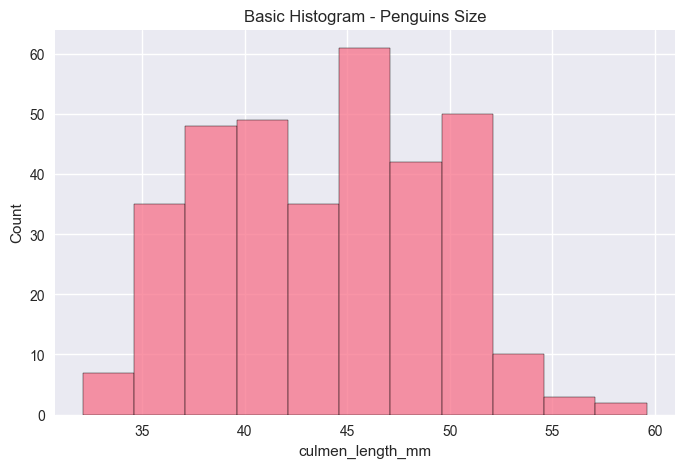

In [7]:
# Case 1: Basic histogram cho Penguins Size
plt.figure(figsize=(8, 5))
sns.histplot(data=penguins_size, x=penguins_size["culmen_length_mm"])
plt.title('Basic Histogram - Penguins Size')
plt.show()

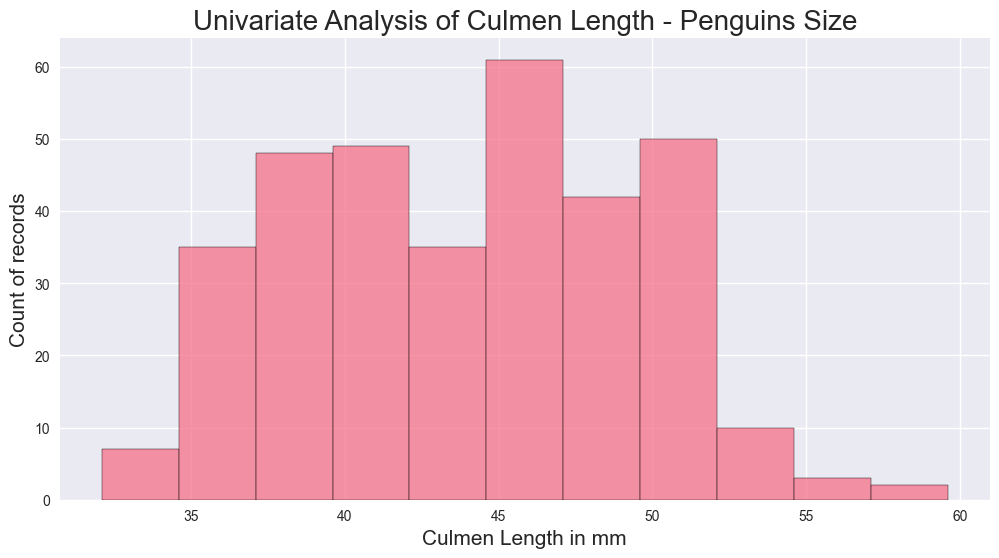

In [8]:
# Case 2: Advanced histogram cho Penguins Size
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=penguins_size, x=penguins_size["culmen_length_mm"])
ax.set_xlabel('Culmen Length in mm', fontsize=15)
ax.set_ylabel('Count of records', fontsize=15)
ax.set_title('Univariate Analysis of Culmen Length - Penguins Size', fontsize=20)
plt.show()

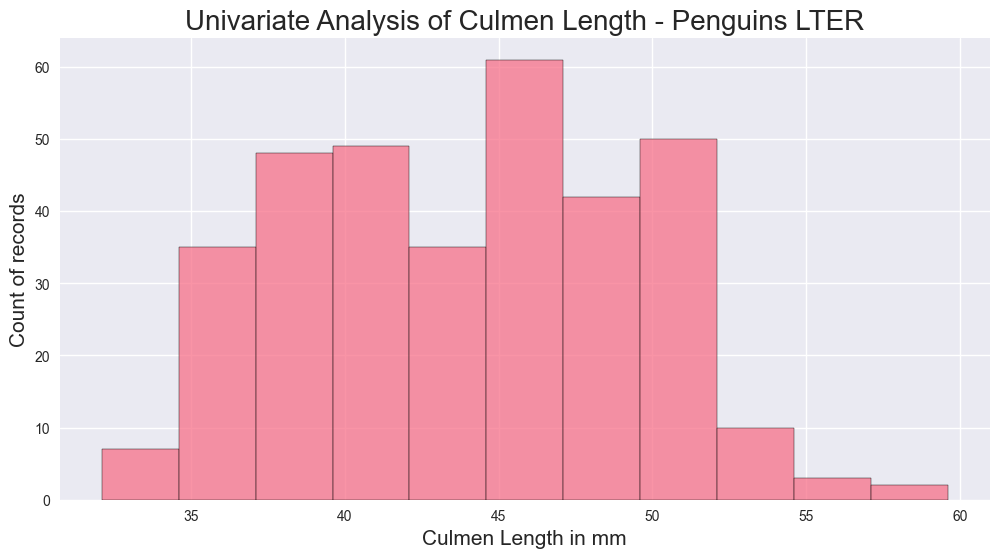

In [9]:
# Tương tự cho Penguins LTER
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=penguins_lter, x=penguins_lter["culmen_length_mm"])
ax.set_xlabel('Culmen Length in mm', fontsize=15)
ax.set_ylabel('Count of records', fontsize=15)
ax.set_title('Univariate Analysis of Culmen Length - Penguins LTER', fontsize=20)
plt.show()

### Nhận Xét
- **Penguins Size**: Phân bố lệch phải nhẹ, đỉnh quanh 35-45 mm cho Adelie, cao hơn cho Gentoo (~45-55 mm).
- **Penguins LTER**: Tương tự, nhưng có thể có sự khác biệt do mẫu nghiên cứu cụ thể; đỉnh chính quanh 40 mm.
- Case 2 cải thiện tính thẩm mỹ với nhãn rõ ràng.

### Kết Luận
Phân bố kích thước mỏ nhất quán giữa hai file, phản ánh sự đa dạng loài. LTER có thể có dữ liệu chi tiết hơn về biến thiên môi trường.

## 3. Phân Tích Đơn Biến Bằng Bar Chart (Cho Species)

Bar chart (countplot) giúp quan sát tần suất của biến phân loại `species` trên cả hai file.

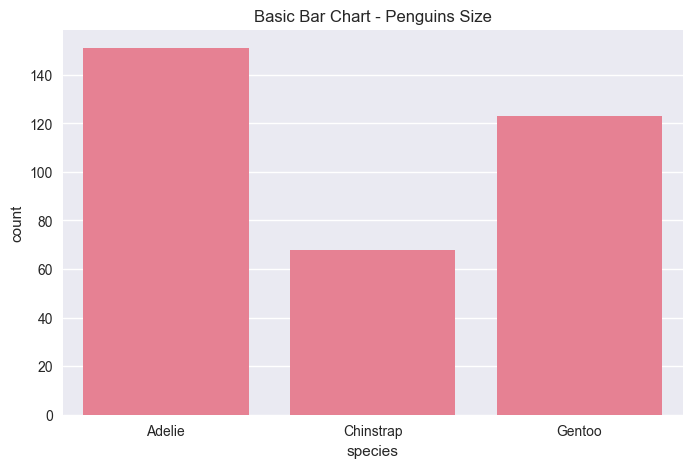

In [10]:
# Case 1: Basic bar chart cho Penguins Size
plt.figure(figsize=(8, 5))
sns.countplot(data=penguins_size, x=penguins_size['species'])
plt.title('Basic Bar Chart - Penguins Size')
plt.show()

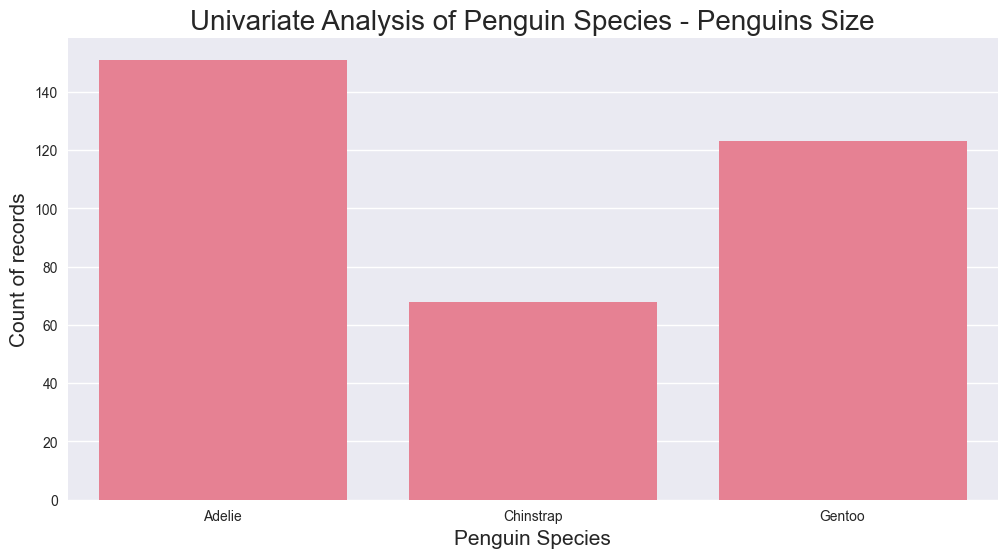

In [11]:
# Case 2: Advanced bar chart cho Penguins Size
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=penguins_size, x=penguins_size['species'])
ax.set_xlabel('Penguin Species', fontsize=15)
ax.set_ylabel('Count of records', fontsize=15)
ax.set_title('Univariate Analysis of Penguin Species - Penguins Size', fontsize=20)
plt.show()

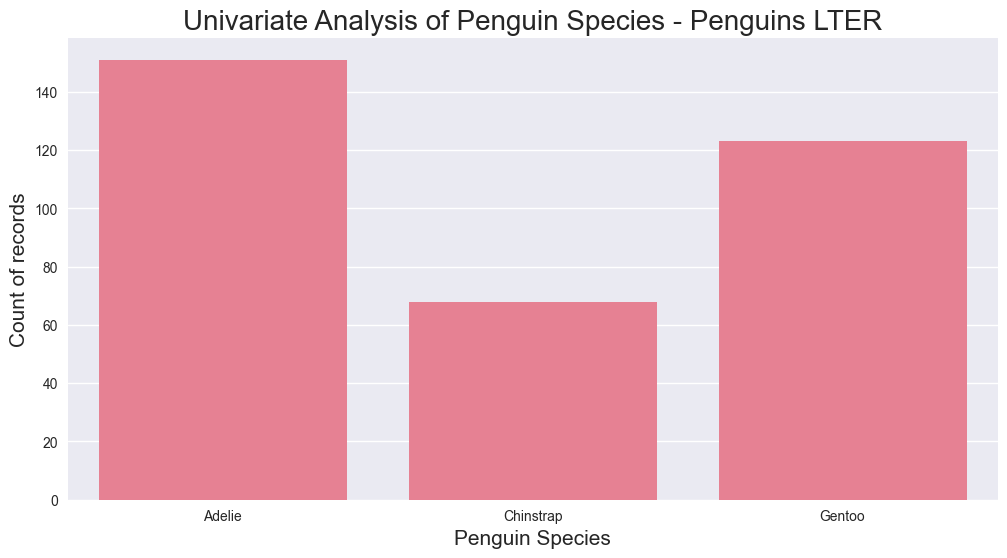

In [12]:
# Tương tự cho Penguins LTER (chuẩn hóa tên species nếu cần)
penguins_lter['species_short'] = penguins_lter['species'].str.split(' ').str[0]  # Lấy tên ngắn (Adelie, Gentoo, Chinstrap)
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=penguins_lter, x=penguins_lter['species_short'])
ax.set_xlabel('Penguin Species', fontsize=15)
ax.set_ylabel('Count of records', fontsize=15)
ax.set_title('Univariate Analysis of Penguin Species - Penguins LTER', fontsize=20)
plt.show()

### Nhận Xét
- **Penguins Size**: Adelie (~152), Gentoo (~124), Chinstrap (~68) – không cân bằng.
- **Penguins LTER**: Tương tự, nhưng có thể có thêm chi tiết về giai đoạn (Adult, Chick), dẫn đến tần suất khác nhẹ.
- Case 2 dễ so sánh hơn.

### Kết Luận
Cấu trúc loài nhất quán, nhưng LTER cung cấp ngữ cảnh nghiên cứu sâu hơn, hữu ích cho phân tích đa biến.

## 4. Phân Tích Đơn Biến Bằng Biểu Đồ Tròn (Pie Chart - Cho Species)

Pie chart hiển thị tỷ lệ phần trăm của từng loài trên cả hai file.

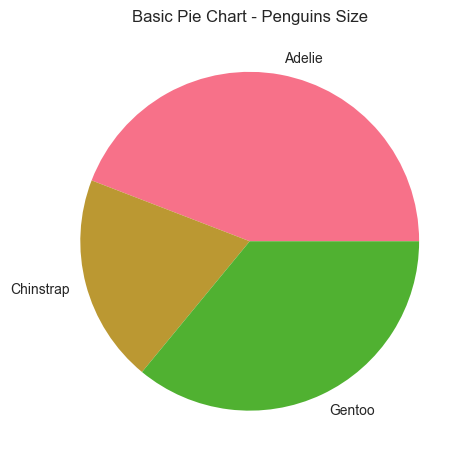

In [13]:
# Groupby cho Penguins Size
penguins_group_size = penguins_size.groupby('species').count().reset_index()

# Case 1: Basic pie chart
plt.pie(penguins_group_size["culmen_length_mm"], labels=penguins_group_size['species'])
plt.title('Basic Pie Chart - Penguins Size')
plt.show()

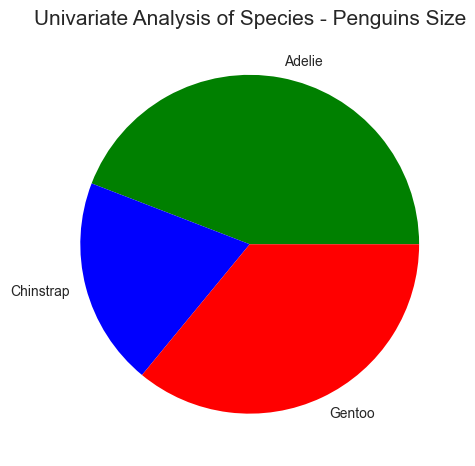

In [14]:
# Case 2: Advanced pie chart cho Penguins Size
cols = ['g', 'b', 'r']
plt.pie(penguins_group_size["culmen_length_mm"], labels=penguins_group_size['species'], colors=cols)
plt.title('Univariate Analysis of Species - Penguins Size', fontsize=15)
plt.show()

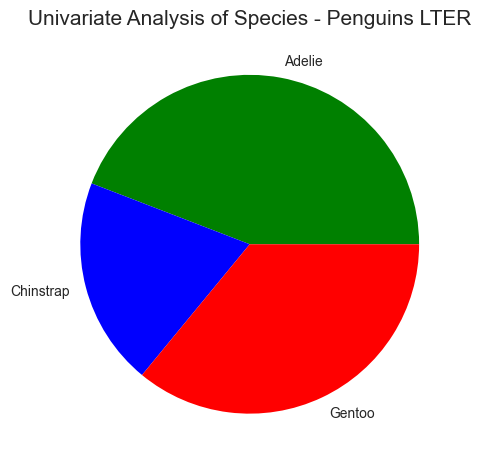

In [15]:
# Tương tự cho Penguins LTER
penguins_group_lter = penguins_lter.groupby('species_short').count().reset_index()
cols = ['g', 'b', 'r']
plt.pie(penguins_group_lter["culmen_length_mm"], labels=penguins_group_lter['species_short'], colors=cols)
plt.title('Univariate Analysis of Species - Penguins LTER', fontsize=15)
plt.show()


### Nhận Xét
- **Penguins Size**: Adelie ~44%, Gentoo ~36%, Chinstrap ~20%.
- **Penguins LTER**: Tỷ lệ tương tự, nhưng có thể lệch do mẫu theo giai đoạn nghiên cứu.
- Màu sắc giúp phân biệt rõ ràng.

### Kết Luận
Tỷ lệ loài giữa hai file nhất quán, xác nhận tính toàn vẹn dataset. Pie chart hiệu quả cho tỷ lệ nhỏ số loại.

## Kết Luận Tổng Quát

- Phân tích đơn biến trên hai file cho thấy sự nhất quán về phân bố kích thước mỏ và tần suất loài, với Adelie chiếm ưu thế.
- Penguins Size phù hợp cho phân tích kích thước vật lý; LTER thêm chiều sâu sinh thái.
- Các biểu đồ advanced (case 2) chuyên nghiệp hơn cho báo cáo.
- Gợi ý mở rộng: Kết hợp hai file để phân tích đa biến (e.g., culmen_length theo species và sex).

